# Main article

In [1]:
import os
import json
from pathlib import Path

# Define directories
real_src = Path("results")
real_dir = Path("results/real")

synth_src = Path("results_synthetic")
synth_dir = Path("results/synthetic")

# Create destination directories if they don't exist
real_dir.mkdir(parents=True, exist_ok=True)
synth_dir.mkdir(parents=True, exist_ok=True)

# Define dataset categories
real_datasets = ["erythroid", "pancreas", "murine", "hindbrain"]

def move_files(src_dir, dest_dir, synth=False):
    # Iterate through files in the source directory
    for filename in os.listdir(src_dir):
        if not filename.endswith(".json"):
            continue
            
        # Condition 2: Only process files with seed 0
        if "seed0" not in filename:
            continue

        # Extract prefix, dataset, and determine if it's "smooth"
        is_smooth = False
        if "_seed0_raw_" in filename:
            prefix, rest = filename.split("_seed0_raw_")
        elif "_seed0_smooth_" in filename:
            prefix, rest = filename.split("_seed0_smooth_")
            is_smooth = True
        else:
            continue  # Skip if it doesn't match the expected pattern

        # The dataset name is whatever comes after the seed/raw/smooth identifier
        dataset = rest.replace(".json", "")

        # Apply renaming rules for the method
        if prefix == "velot":
            method = "OT"
        elif prefix == "velot_gradient":
            method = "knn"
        elif prefix == "velot_unbalanced":
            method = "OT"
        else:
            continue # Skip unrecognized prefixes

        # Append _MLP if the original file was "smooth"
        if is_smooth:
            method += "_MLP"

        # Condition 1: Determine the target folder based on dataset name
        if not synth and dataset in real_datasets:
            pass
        elif synth and dataset not in real_datasets:
            pass
        else:
            continue

        # Construct final file paths
        new_filename = f"{method}_{dataset}.json"
        src_path = src_dir / filename
        dest_path = dest_dir / new_filename

        # Read the original JSON
        with open(src_path, "r") as f:
            data = json.load(f)
        
        # Update the 'model' key to the new method name
        if "model" in data:
            data["model"] = method

        # Write the modified JSON to the new destination
        with open(dest_path, "w") as f:
            json.dump(data, f, indent=4)  # indent=4 keeps the JSON human-readable

        print(f"Processed: {filename} -> {dest_dir.name}/{new_filename}")

In [2]:
move_files(synth_src, synth_dir, True)

Processed: velot_seed0_raw_linear.json -> synthetic/OT_linear.json
Processed: velot_seed0_smooth_linear.json -> synthetic/OT_MLP_linear.json
Processed: velot_gradient_seed0_raw_linear.json -> synthetic/knn_linear.json
Processed: velot_gradient_seed0_smooth_linear.json -> synthetic/knn_MLP_linear.json
Processed: velot_seed0_raw_bifurcation.json -> synthetic/OT_bifurcation.json
Processed: velot_seed0_smooth_bifurcation.json -> synthetic/OT_MLP_bifurcation.json
Processed: velot_gradient_seed0_raw_bifurcation.json -> synthetic/knn_bifurcation.json
Processed: velot_gradient_seed0_smooth_bifurcation.json -> synthetic/knn_MLP_bifurcation.json
Processed: velot_seed0_raw_trifurcation.json -> synthetic/OT_trifurcation.json
Processed: velot_seed0_smooth_trifurcation.json -> synthetic/OT_MLP_trifurcation.json
Processed: velot_gradient_seed0_raw_trifurcation.json -> synthetic/knn_trifurcation.json
Processed: velot_gradient_seed0_smooth_trifurcation.json -> synthetic/knn_MLP_trifurcation.json


## Figure 5: dotplot

In [3]:
from velot.benchmark import benchmark_summary_table

benchmark_summary_table(
    "results/real",
    detail="per_dataset",
    save_csv="results/real/summary_per_dataset.csv",
)
benchmark_summary_table(
    "results/synthetic",
    detail="per_dataset",
    save_csv="results/synthetic/summary_per_dataset.csv",
)

  Saved summary table: results/real/summary_per_dataset.csv
  Saved summary table: results/synthetic/summary_per_dataset.csv


,model,dataset,metric,mean,median,std,n,pvalue,significance,time_total
0,OT,bifurcation,cbdir,0.888620,1.000000,0.244903,868,NaN,,9.792715
1,OT,bifurcation,iccoh,0.197712,0.165474,0.158988,4997,NaN,,9.792715
2,OT,linear,cbdir,0.955006,1.000000,0.122059,855,NaN,,9.727265
3,OT,linear,iccoh,0.122602,0.113455,0.078795,4998,NaN,,9.727265
4,OT,trifurcation,cbdir,0.879595,1.000000,0.248036,1217,NaN,,9.953334
5,OT,trifurcation,iccoh,0.242342,0.211397,0.196764,4990,NaN,,9.953334
6,OT_MLP,bifurcation,cbdir,0.938597,1.000000,0.146050,868,NaN,,9.792715
7,OT_MLP,bifurcation,iccoh,0.954580,0.961437,0.031505,4997,NaN,,9.792715
8,OT_MLP,linear,cbdir,0.963569,1.000000,0.080160,855,NaN,,9.727265
9,OT_MLP,linear,iccoh,0.871299,0.869121,0.060644,4998,NaN,,9.727265


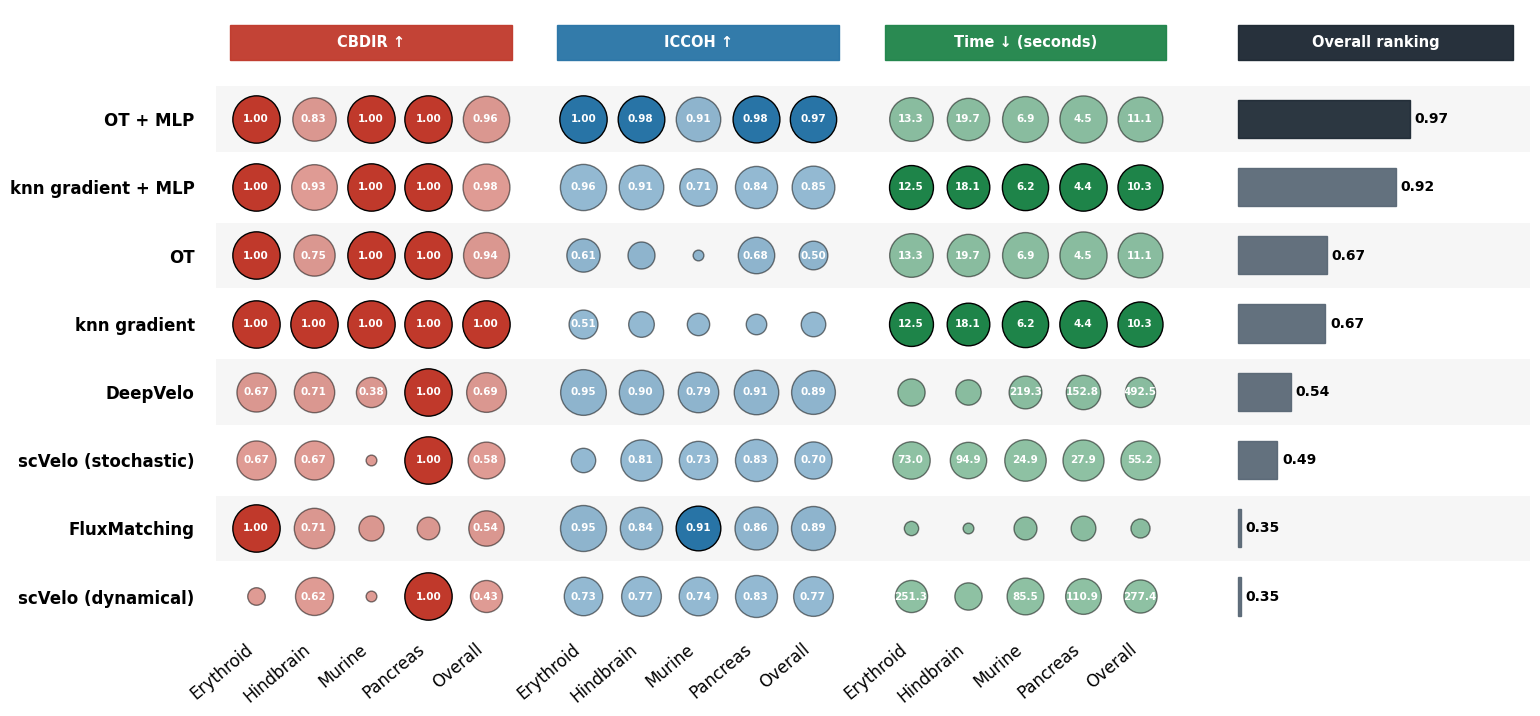

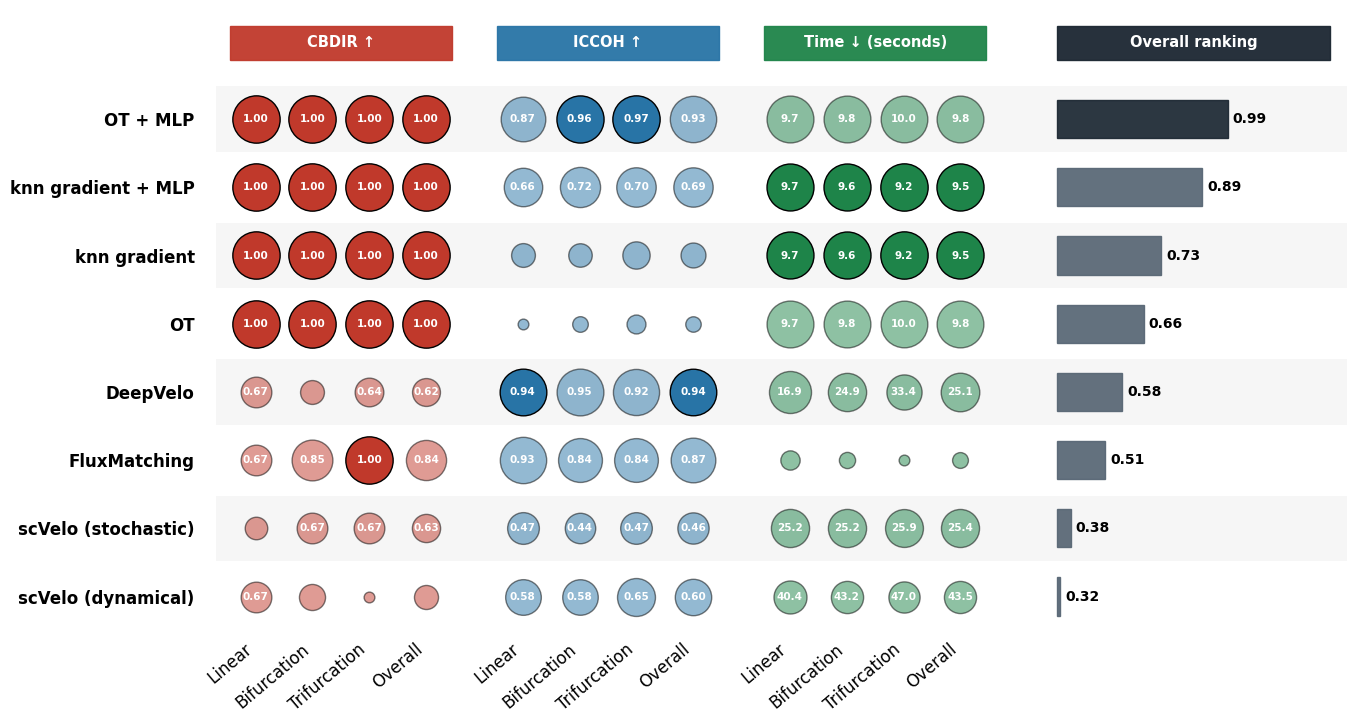

In [4]:
from velot.benchmark import benchmark_dotplot

benchmark_dotplot("results/real", stat="median",
    model_labels={
        "OT": "OT",
        "knn": "knn gradient",
        "OT_MLP": "OT + MLP",
        "knn_MLP": "knn gradient + MLP",
        "scvelo_dynamical": "scVelo (dynamical)",
        "scvelo_stochastic": "scVelo (stochastic)",
        "deepvelo": "DeepVelo",
        "flux_matching": "FluxMatching",
    },
    legend=False, summary=False,
    # save="../figures/figure 5/figure5_a.png"
    );

benchmark_dotplot("results/synthetic", stat="median",
    model_labels={
        "OT": "OT",
        "knn": "knn gradient",
        "OT_MLP": "OT + MLP",
        "knn_MLP": "knn gradient + MLP",
        "scvelo_dynamical": "scVelo (dynamical)",
        "scvelo_stochastic": "scVelo (stochastic)",
        "deepvelo": "DeepVelo",
        "flux_matching": "FluxMatching",
    },
    datasets_order=["linear", "bifurcation", "trifurcation"],
    legend=False, summary=False,
    # save="../figures/figure 5/figure5_b.png"
    );

# Supplementary

## Figure: boxplots benchmark

In [1]:
from velot.benchmark import benchmark_comparison_individual

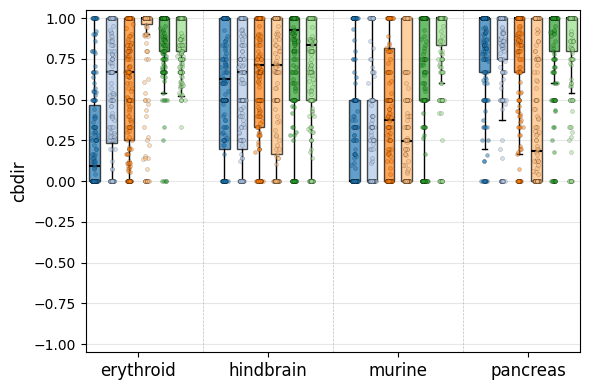

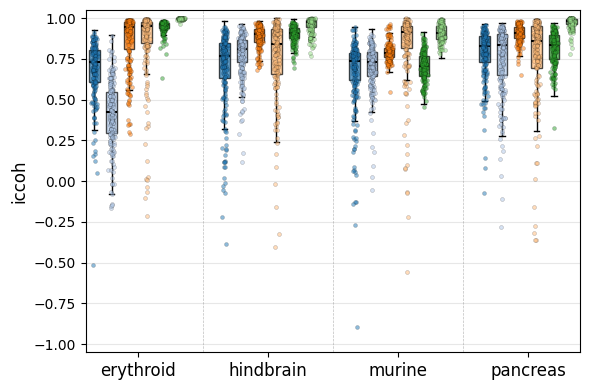

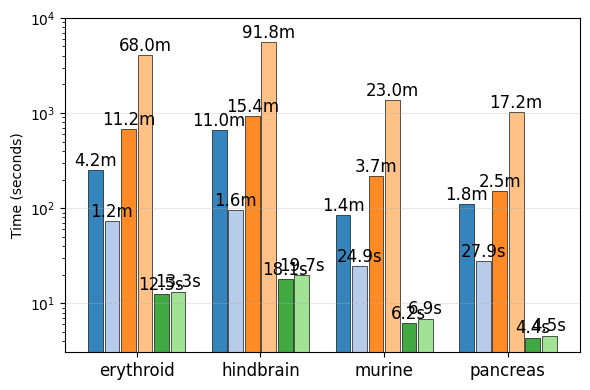

Saved benchmark_boxplots_legend.png


In [2]:
benchmark_comparison_individual(
    "results/real",
    models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "knn_MLP", "OT_MLP"],
    detail="per_dataset",
    reference_model=None,
    save=True, save_path="../supplementary", save_prefix="benchmark_boxplots", ylim_timing=10**4, save_legend=True
);

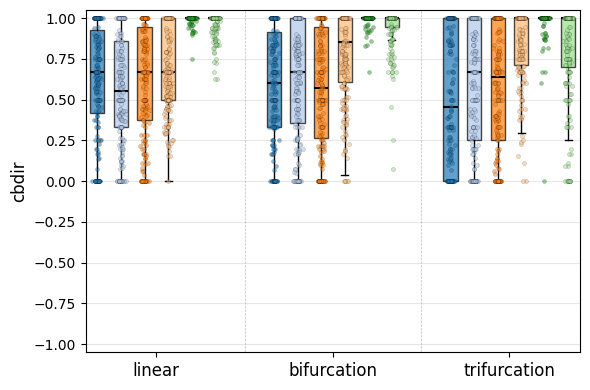

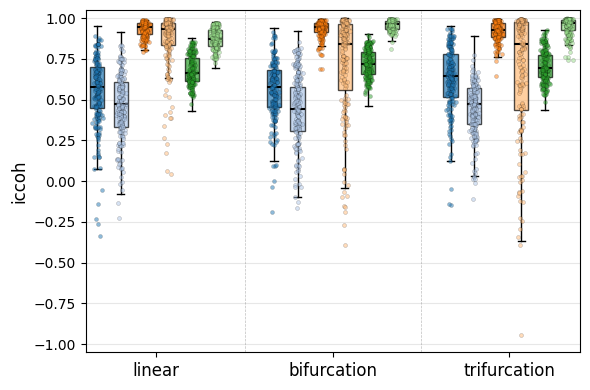

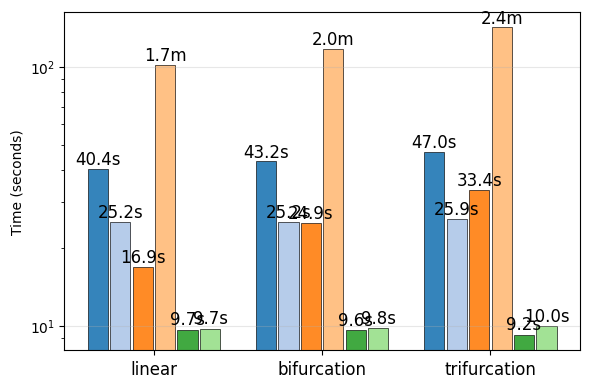

Saved benchmark_boxplots_synthetic_legend.png


In [3]:
benchmark_comparison_individual(
    "results/synthetic",
    models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "knn_MLP", "OT_MLP"],
    detail="per_dataset",
    reference_model=None, datasets_order=["linear", "bifurcation", "trifurcation"],
    save=True, save_path="../supplementary", save_prefix="benchmark_boxplots_synthetic", save_legend=True
);

## Figure: heatmaps (not shown)

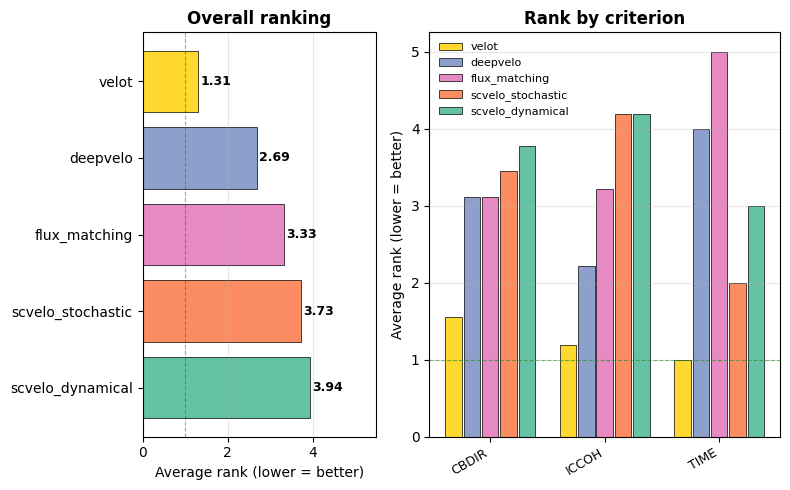

In [3]:
from velot.benchmark import benchmark_heatmaps, benchmark_ranking

# # ── Heatmaps ────────────────────────────────────────────────────

# # Mean performance per model × dataset
# benchmark_heatmaps("benchmark_results/real", stat="mean", cmap="Blues")

# # Median
# benchmark_heatmaps("benchmark_results/real", stat="median", cmap="Blues")

# # Average rank (most robust comparison)
# benchmark_heatmaps(
#     "benchmark_results/real", stat="rank", cmap="Blues",
#     save=None,
# )

# ── Overall ranking summary ────────────────────────────────────

benchmark_ranking(
    "benchmark_results/real",
    models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "velot"],
    save=None,
);

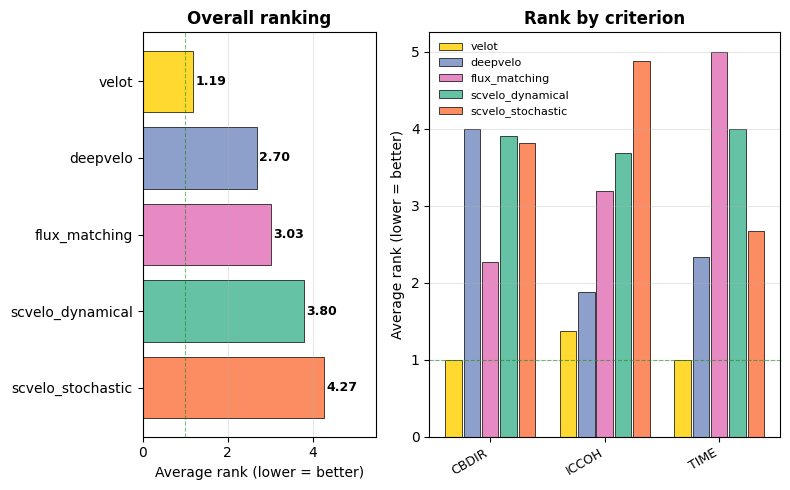

In [5]:
benchmark_ranking(
    "benchmark_results/synthetic",
    models_order=["scvelo_dynamical", "scvelo_stochastic", "deepvelo", "flux_matching", "velot"],
    save=None,
);

## Figure: velocity stream comparison

In [41]:
import velot
import os
import scanpy as sc
import scvelo as scv

results_path = "/home/lucas/Documents/velot/article/benchmark/benchmark_results/synthetic2/data"
files = sorted(os.listdir(results_path))

files

['deepvelo_bifurcation.h5ad',
 'deepvelo_linear.h5ad',
 'deepvelo_trifurcation.h5ad',
 'scvelo_dynamical_bifurcation.h5ad',
 'scvelo_dynamical_linear.h5ad',
 'scvelo_dynamical_trifurcation.h5ad',
 'scvelo_stochastic_bifurcation.h5ad',
 'scvelo_stochastic_linear.h5ad',
 'scvelo_stochastic_trifurcation.h5ad',
 'velot_bifurcation.h5ad',
 'velot_linear.h5ad',
 'velot_trifurcation.h5ad']

In [25]:
for file in np.array(files):
    print(file)
    adata = sc.read_h5ad(os.path.join(results_path, file))
    print(adata)
    print()

deepvelo_bifurcation.h5ad
AnnData object with n_obs × n_vars = 5000 × 60
    obs: 'step_ix', 'simulation_i', 'sim_time', 'milestone', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna', 'mol_protein'
    uns: 'neighbors', 'pca', 'traj_dimred_segments', 'traj_milestone_network', 'traj_progressions'
    obsm: 'X_hvg', 'X_pca', 'dimred', 'velocity_hvg'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'cell_specific_beta', 'cell_specific_gamma', 'counts_protein', 'counts_spliced', 'counts_unspliced', 'logcounts', 'rna_velocity', 'spliced', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

deepvelo_linear.h5ad
AnnData object with n_obs × n_vars = 5000 × 51
    obs: 'step_ix', '

In [14]:
from pathlib import Path
import scvelo as scv
import scanpy as sc
import matplotlib.pyplot as plt
import velot

def plot_benchmark_grid(
    data_dir,
    datasets,
    models,
    clusters_map=None,
    basis_map=None,
    velocity_map=None,
    dataset_order=None,
    model_order=None,
    figsize_per_panel=(5,5),
):
    """
    Grid plot: rows=datasets, cols=models using scvelo streamplot.
    """

    data_dir = Path(data_dir)

    # --- ordering ---
    if dataset_order is not None:
        datasets = dataset_order

    if model_order is not None:
        models = model_order

    n_rows = len(datasets)
    n_cols = len(models)

    figsize = (figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

    if n_rows == 1:
        axes = [axes]
    if n_cols == 1:
        axes = [[ax] for ax in axes]

    for i, dataset in enumerate(datasets):
        for j, model in enumerate(models):

            ax = axes[i][j]

            # file matching
            files = list(data_dir.glob(f"*{model}*{dataset}*.h5ad"))
            if len(files) == 0:
                ax.set_title("missing")
                ax.axis("off")
                continue

            adata = sc.read_h5ad(files[0])

            basis_key = (basis_map or {}).get((dataset, model), "umap")
            velocity_key = (velocity_map or {}).get((dataset, model), None)
            clusters_key = (clusters_map or {}).get((dataset), None)

            if velocity_key is None:
                velocity_key = "velocity"

            print(f"Plotting {dataset} - {model} with basis={basis_key}, velocity_key={velocity_key}, clusters_key={clusters_key}")

            # if model == "velot":
            #     velot.tl.project_to_embedding(adata)
                
            scv.pl.velocity_embedding_stream(
                adata, basis=basis_key, vkey=velocity_key, color=clusters_key,
                title="", ax=ax, show=False
            )

            # column titles (top row only)
            if i == 0:
                ax.set_title(model, fontsize=16, fontweight="bold", pad=20)

            # row labels (left side only)
            if j == 0:
                ax.annotate(
                    dataset,
                    xy=(-0.25, 0.5),
                    xycoords="axes fraction",
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=16,
                    fontweight="bold"
                )

                velot.pl.add_umap_axis(ax, basis=basis_key)

    plt.tight_layout()
    return fig

In [15]:
datasets = ["erythroid", "hindbrain", "murine", "pancreas"]
# dataset_order = ["pancreas", "murine", "hindbrain", "erythroid"]
basis_map = {
    ("hindbrain", "scvelo_dynamical"): "tsne",
    ("hindbrain", "scvelo_stochastic"): "tsne",
    ("hindbrain", "OT_MLP"): "tsne",
    ("hindbrain", "knn_MLP"): "tsne",
    ("hindbrain", "flux_matching"): "tsne",
    ("hindbrain", "deepvelo"): "tsne"

}

clusters_map = {
    "erythroid": "celltype",
    "hindbrain": "Celltype",
    "murine": "cell_type",
    "pancreas": "clusters"
}

velocity_map = {
    ("erythroid", "scvelo_dynamical"): "dynvelo",
    ("erythroid", "scvelo_stochastic"): "stocvelo",
    ("erythroid", "OT_MLP"): "velot_velocity",
    ("erythroid", "knn_MLP"): "velot_velocity",
    ("erythroid", "deepvelo"): "velocity",
    ("erythroid", "flux_matching"): "velocity",
    ("hindbrain", "scvelo_dynamical"): "dynvelo",
    ("hindbrain", "scvelo_stochastic"): "stocvelo",
    ("hindbrain", "OT_MLP"): "velot_velocity",
    ("hindbrain", "knn_MLP"): "velot_velocity",
    ("hindbrain", "deepvelo"): "velocity",
    ("hindbrain", "flux_matching"): "velocity",
    ("murine", "scvelo_dynamical"): "dynvelo",
    ("murine", "scvelo_stochastic"): "stocvelo",
    ("murine", "OT_MLP"): "velot_velocity",
    ("murine", "knn_MLP"): "velot_velocity",
    ("murine", "deepvelo"): "velocity",
    ("murine", "flux_matching"): "velocity",
    ("pancreas", "scvelo_dynamical"): "dynvelo",
    ("pancreas", "scvelo_stochastic"): "stocvelo",
    ("pancreas", "OT_MLP"): "velot_velocity",
    ("pancreas", "knn_MLP"): "velot_velocity",
    ("pancreas", "deepvelo"): "velocity",
    ("pancreas", "flux_matching"): "velocity"
}

models = [
    "scvelo_stochastic",
    "scvelo_dynamical",
    "deepvelo",
    "flux_matching",
    "knn_MLP",
    "OT_MLP"
]

Plotting erythroid - scvelo_stochastic with basis=umap, velocity_key=stocvelo, clusters_key=celltype
computing velocity embedding
    finished (0:00:01) --> added
    'stocvelo_umap', embedded velocity vectors (adata.obsm)
Plotting erythroid - scvelo_dynamical with basis=umap, velocity_key=dynvelo, clusters_key=celltype
computing velocity embedding
    finished (0:00:01) --> added
    'dynvelo_umap', embedded velocity vectors (adata.obsm)
Plotting erythroid - deepvelo with basis=umap, velocity_key=velocity, clusters_key=celltype
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
Plotting erythroid - flux_matching with basis=umap, velocity_key=velocity, clusters_key=celltype
Plotting erythroid - knn_MLP with basis=umap, velocity_key=velot_velocity, clusters_key=celltype
Plotting erythroid - OT_MLP with basis=umap, velocity_key=velot_velocity, clusters_key=celltype
Plotting hindbrain - scvelo_stochastic with basis=tsn

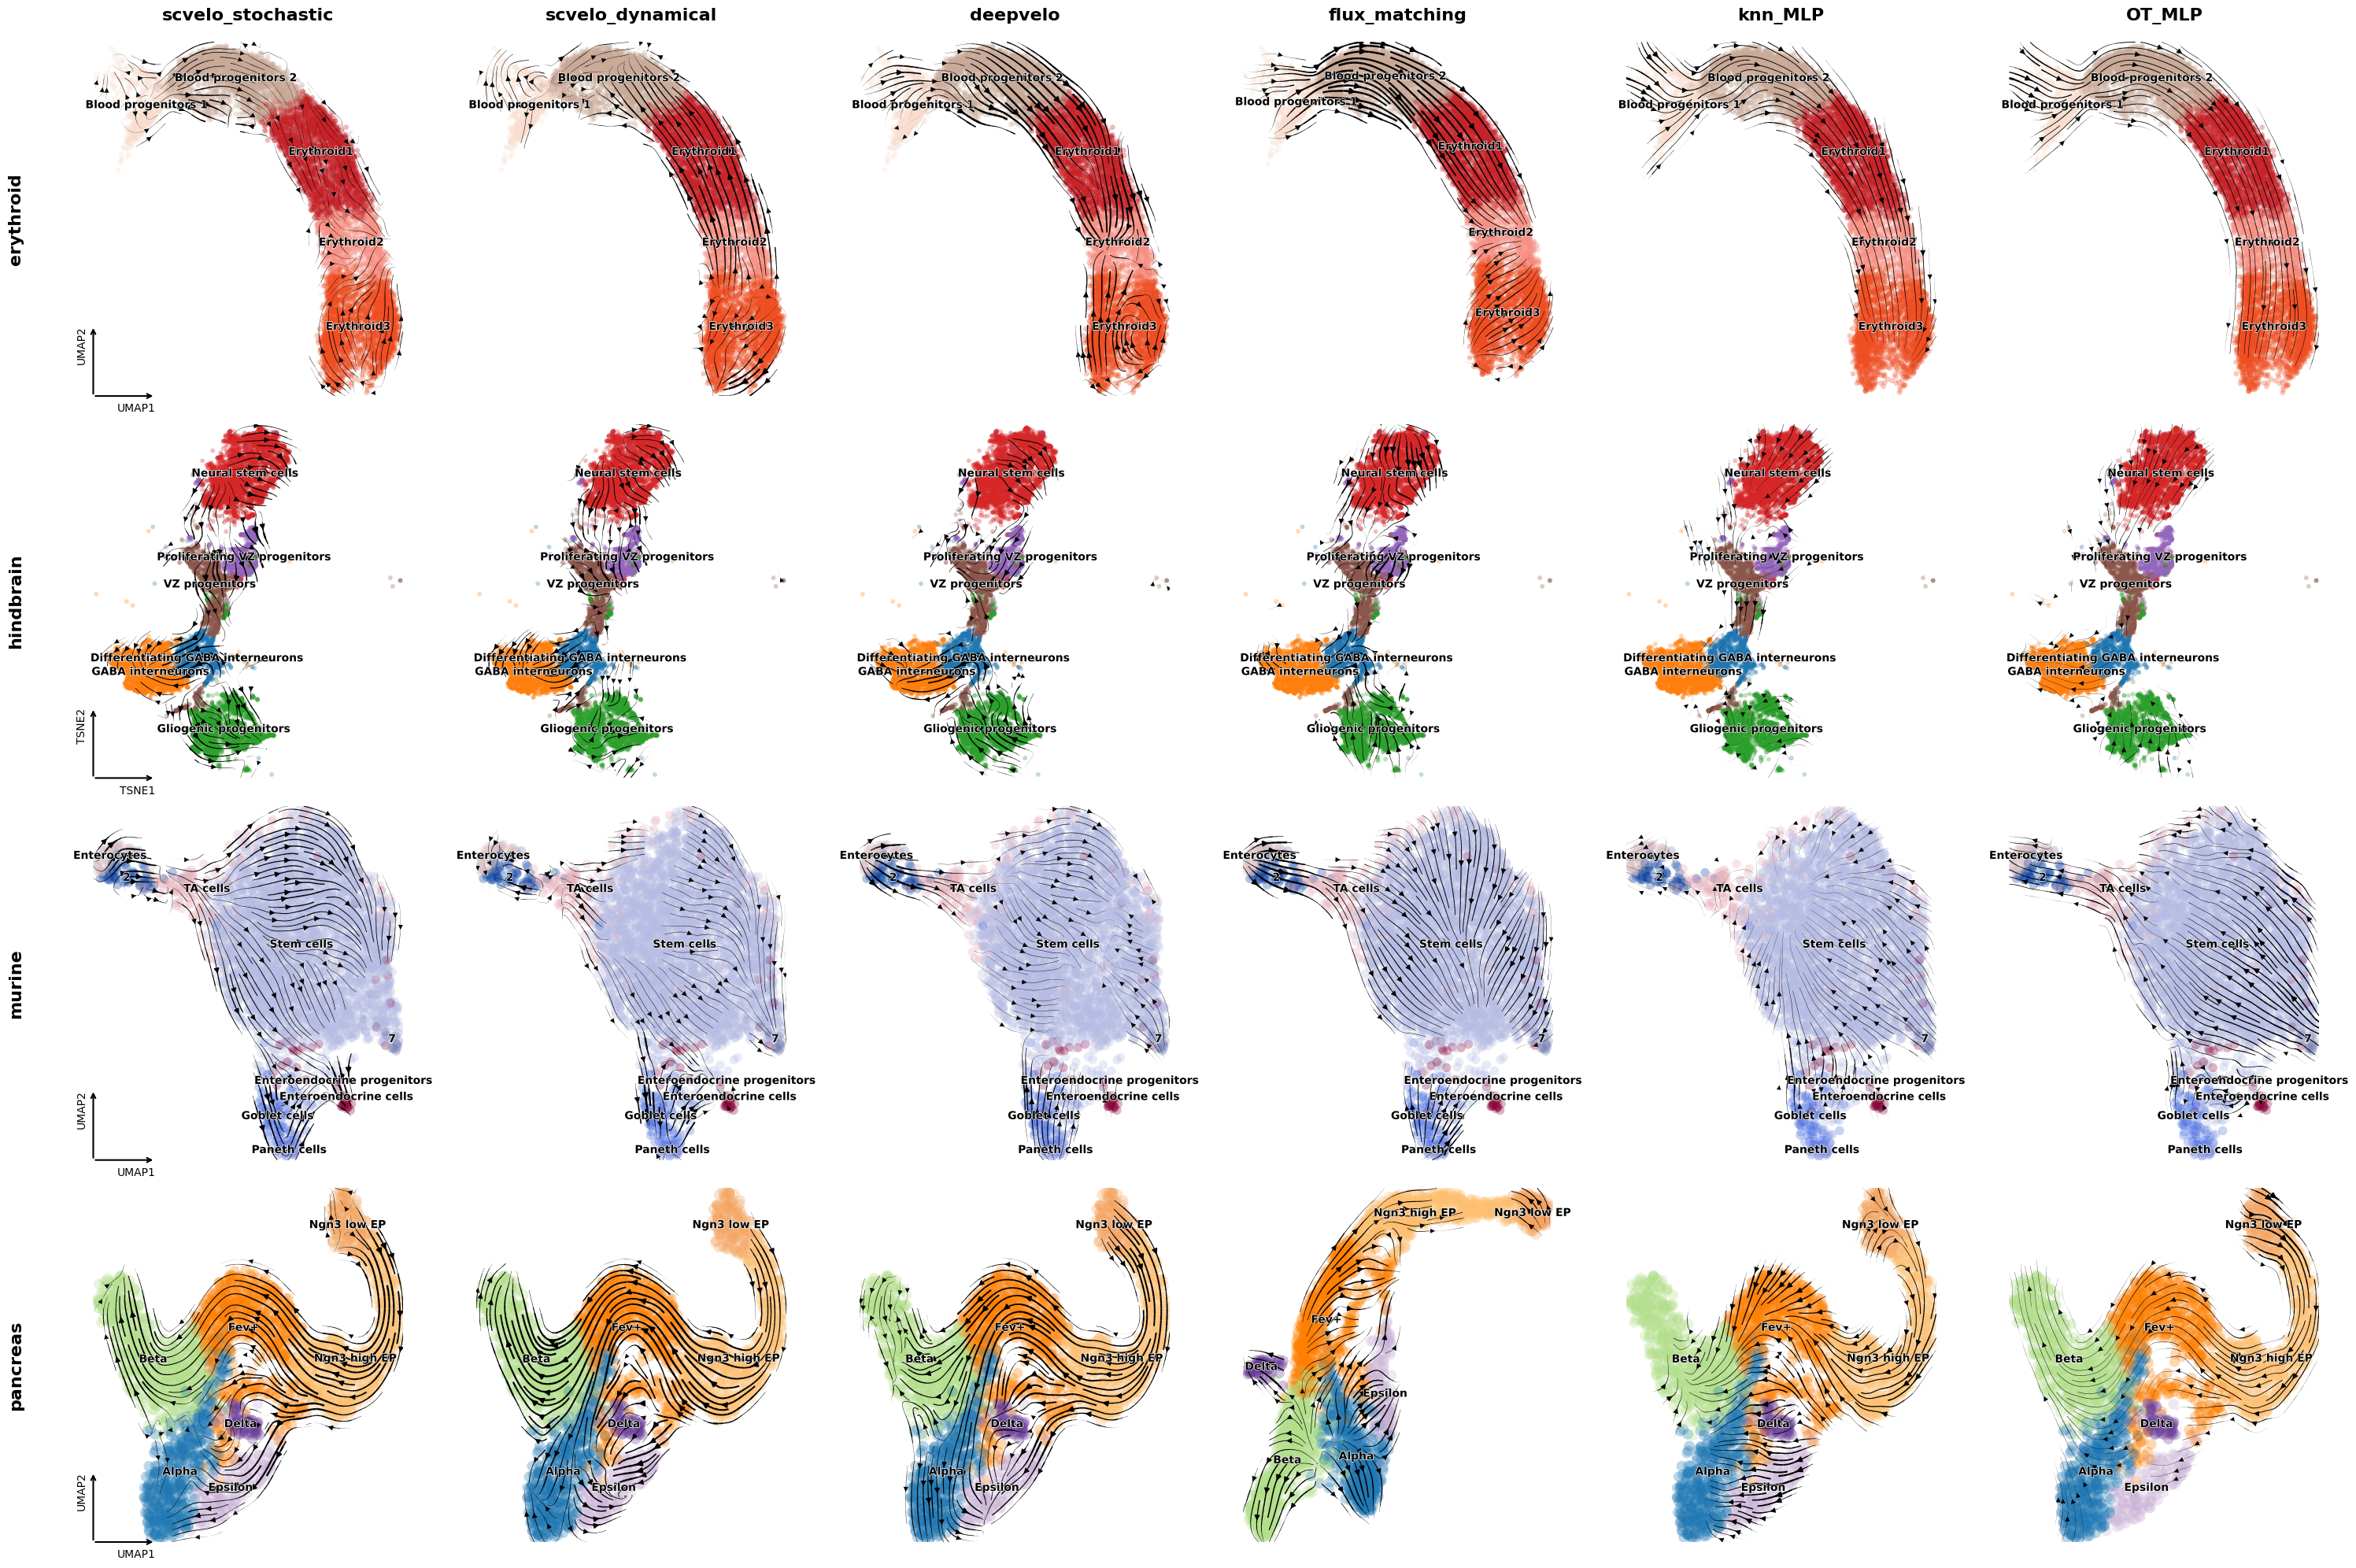

In [16]:
fig = plot_benchmark_grid(
    data_dir="results/real/data",
    clusters_map=clusters_map,
    datasets=datasets,
    models=models,
    basis_map=basis_map,
    velocity_map=velocity_map,
    # dataset_order=dataset_order,
)

In [17]:
fig.savefig("../supplementary/velocity_stream_real.png", dpi=300)

In [18]:
datasets = ["linear", "bifurcation", "trifurcation"]
dataset_order = ["linear", "bifurcation", "trifurcation"]

clusters_map = {
    "linear": "milestone",
    "bifurcation": "milestone",
    "trifurcation": "milestone"
}

velocity_map = {
    ("linear", "scvelo_dynamical"): "dynvelo",
    ("linear", "scvelo_stochastic"): "stocvelo",
    ("linear", "knn_MLP"): "velot_velocity",
    ("linear", "OT_MLP"): "velot_velocity",
    ("linear", "deepvelo"): "velocity",
    ("linear", "flux_matching"): "velocity",
    ("bifurcation", "scvelo_dynamical"): "dynvelo",
    ("bifurcation", "scvelo_stochastic"): "stocvelo",
    ("bifurcation", "knn_MLP"): "velot_velocity",
    ("bifurcation", "OT_MLP"): "velot_velocity",
    ("bifurcation", "deepvelo"): "velocity",
    ("bifurcation", "flux_matching"): "velocity",
    ("trifurcation", "scvelo_dynamical"): "dynvelo",
    ("trifurcation", "scvelo_stochastic"): "stocvelo",
    ("trifurcation", "knn_MLP"): "velot_velocity",
    ("trifurcation", "OT_MLP"): "velot_velocity",
    ("trifurcation", "deepvelo"): "velocity",
    ("trifurcation", "flux_matching"): "velocity"
}

models = [
    "scvelo_stochastic",
    "scvelo_dynamical",
    "deepvelo",
    "flux_matching",
    "knn_MLP",
    "OT_MLP"
]

Plotting linear - scvelo_stochastic with basis=umap, velocity_key=stocvelo, clusters_key=milestone
computing velocity embedding
    finished (0:00:00) --> added
    'stocvelo_umap', embedded velocity vectors (adata.obsm)
Plotting linear - scvelo_dynamical with basis=umap, velocity_key=dynvelo, clusters_key=milestone
computing velocity embedding
    finished (0:00:00) --> added
    'dynvelo_umap', embedded velocity vectors (adata.obsm)
Plotting linear - deepvelo with basis=umap, velocity_key=velocity, clusters_key=milestone
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
Plotting linear - flux_matching with basis=umap, velocity_key=velocity, clusters_key=milestone
Plotting linear - knn_MLP with basis=umap, velocity_key=velot_velocity, clusters_key=milestone
Plotting linear - OT_MLP with basis=umap, velocity_key=velot_velocity, clusters_key=milestone
Plotting bifurcation - scvelo_stochastic with basis=umap, velocit

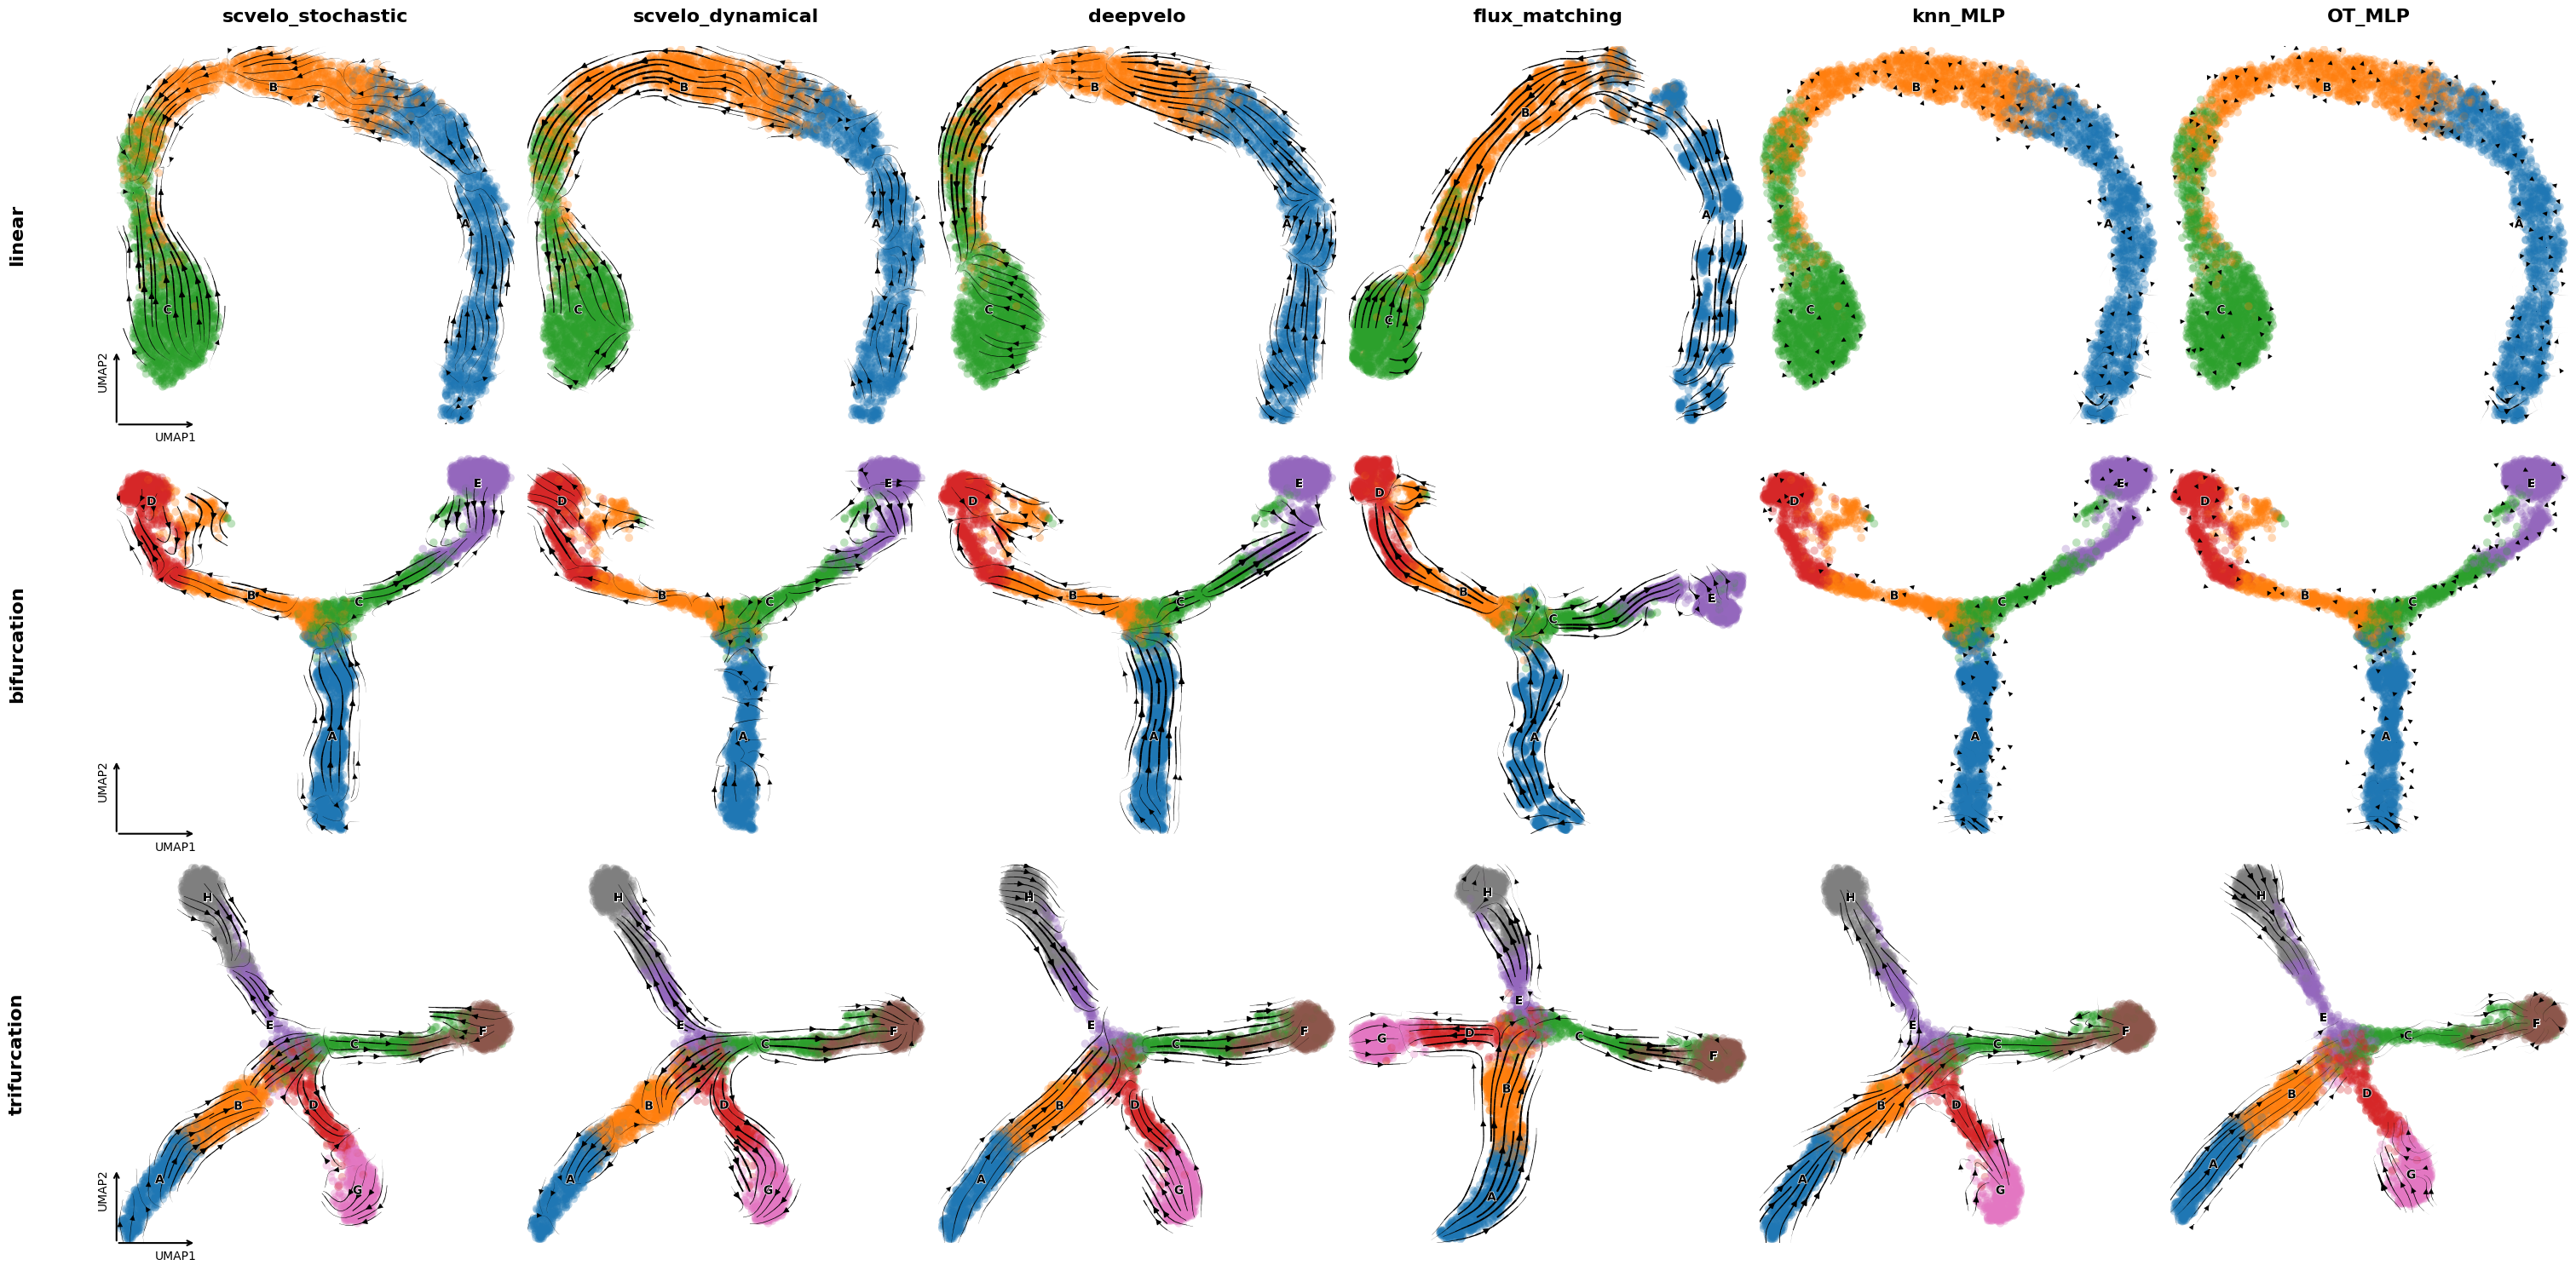

In [19]:
fig = plot_benchmark_grid(
    data_dir="results/synthetic/data",
    clusters_map=clusters_map,
    datasets=datasets,
    models=models,
    velocity_map=velocity_map,
    dataset_order=dataset_order
)

In [20]:
fig.savefig("../supplementary/velocity_stream_synthetic.png", dpi=300)